# Introduction

Objective of this notebook is to explore customer behavior, sales performance and operational metrics using the analytical datasets prepared in PostgreSQL.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

# Data Load

In [3]:
from src.database import load_view

df_customers = load_view("vw_customer_summary_python")
df_monthly_sales = load_view("vw_monthly_sales_summary")
df_products = load_view("vw_products_summary")
df_delivery = load_view("vw_delivery_summary")
df_reviews = load_view("vw_order_review_summary")

# Monthly Sales Summary Overview

In [4]:
df_monthly_sales.tail()

,purchase_month,total_orders,total_customers,total_revenue,avg_order_value,avg_orders_per_customer,cancelled_orders,cancellation_rate,unavailable_orders,unavailable_rate
20,2018-06-01,6167,6128,"1,023,880.50",166.03,1,18,0.29,4,0.06
21,2018-07-01,6292,6230,"1,066,540.75",169.51,1,41,0.65,18,0.29
22,2018-08-01,6512,6460,"1,022,425.32",157.01,1,84,1.29,7,0.11
23,2018-09-01,16,14,"4,439.54",277.47,1,15,93.75,0,0.00
24,2018-10-01,4,4,589.67,147.42,1,4,100.00,0,0.00


Dataset ends in August 2018, all data in September and October represent transactions whose processing or cancellation was delayed in system time and should be excluded from trend analysis.

In [5]:
df_monthly_sales_clean = df_monthly_sales[df_monthly_sales['purchase_month'] < '2018-09-01']

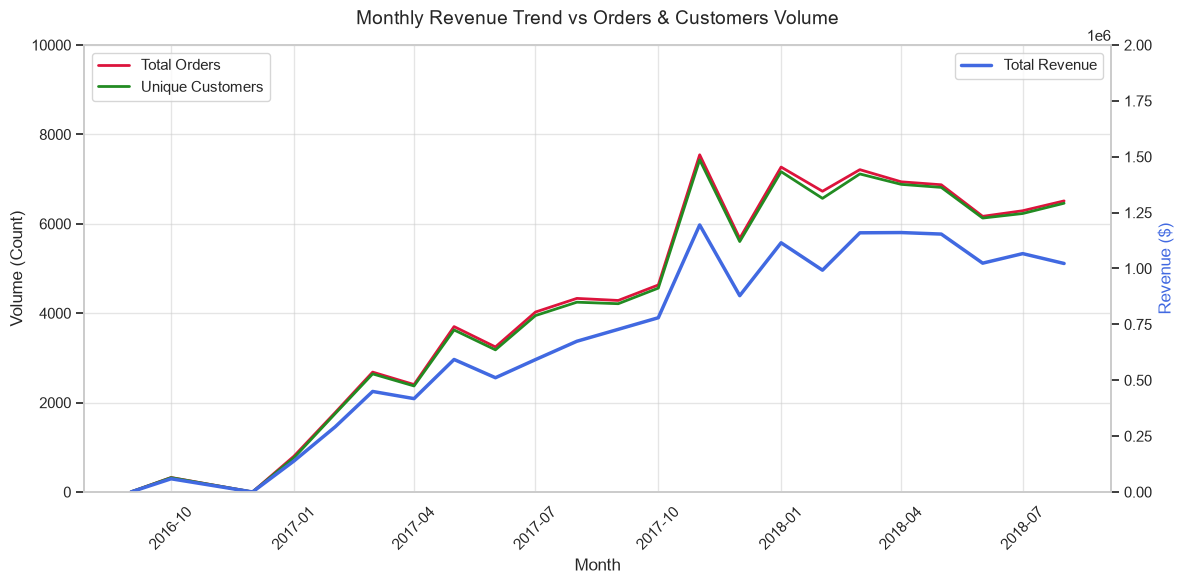

In [6]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_orders',
             ax=ax1, color='crimson', label='Total Orders', linewidth=2)
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_customers',
             ax=ax1, color='forestgreen', label='Unique Customers', linewidth=2)

ax1.set_ylabel('Volume (Count)')
ax1.set_ylim(0,10000)
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_revenue',
             ax=ax2, color='royalblue', label='Total Revenue', linewidth=2.5)

ax2.set_ylabel('Revenue ($)', color='royalblue')
ax2.set_ylim(0,2000000)
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Revenue Trend vs Orders & Customers Volume', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The near-identical alignment between unique customers and total orders highlights a low retention rate, proving the business relies almost entirely on new customers. Furthermore, since the revenue trend scales proportionally with order volume, growth remains linear rather than exponential, indicating that the platform's monetary performance is entirely bound to scaling transaction numbers.

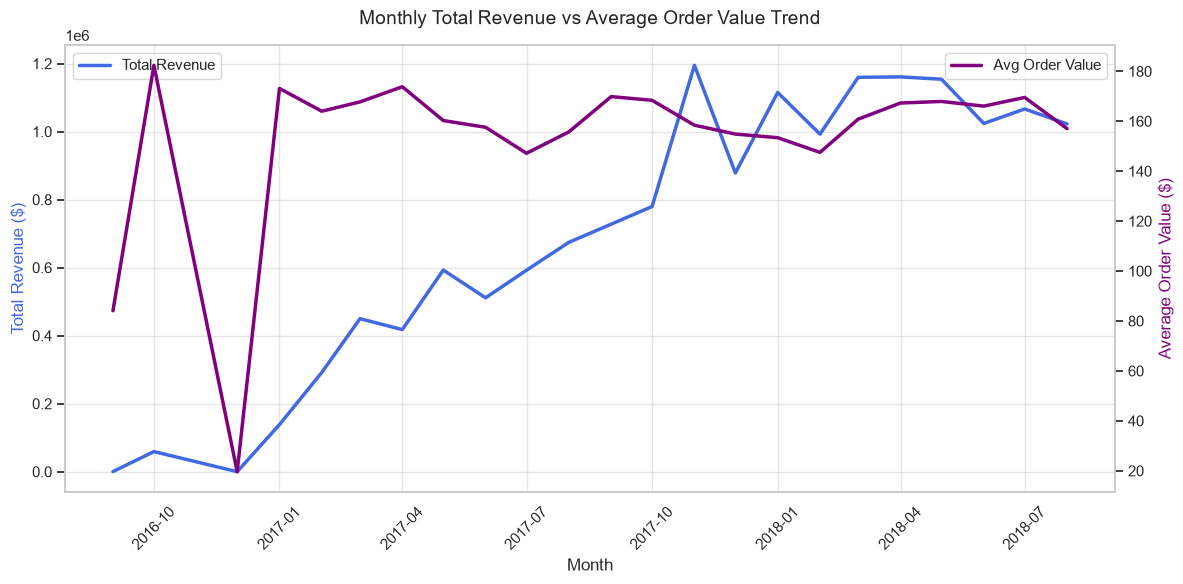

In [7]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_revenue',
             ax=ax1, color='royalblue', label='Total Revenue', linewidth=2.5)

ax1.set_ylabel('Total Revenue ($)', color='royalblue')
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='avg_order_value',
             ax=ax2, color='purple', label='Avg Order Value', linewidth=2.5)

ax2.set_ylabel('Average Order Value ($)', color='purple')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Total Revenue vs Average Order Value Trend', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Comparison of Total Revenue and Average Order Value further supports that business scales through volume as Average Order Value remains almost flat throughout analyzed period.

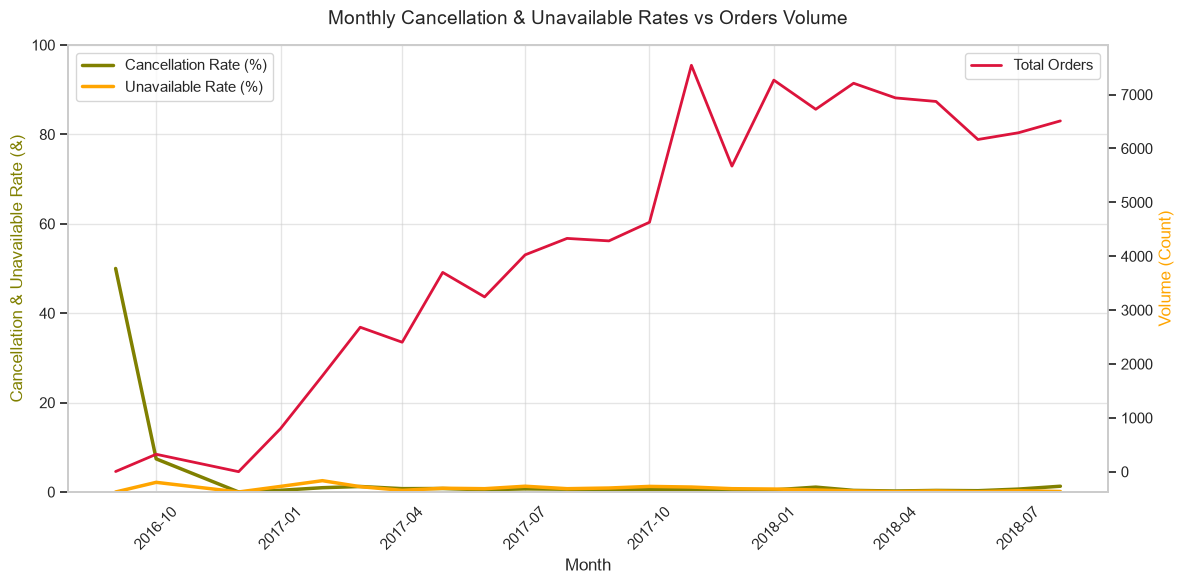

In [8]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='cancellation_rate',
             ax=ax1, color='olive', label='Cancellation Rate (%)', linewidth=2.5)
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='unavailable_rate',
             ax=ax1, color='orange', label='Unavailable Rate (%)', linewidth=2.5)

ax1.set_ylabel('Cancellation & Unavailable Rate (&)', color='olive')
ax1.set_ylim(0,100)
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_monthly_sales_clean, x='purchase_month', y='total_orders',
             ax=ax2, color='crimson', label='Total Orders', linewidth=2)

ax2.set_ylabel('Volume (Count)', color='orange')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Monthly Cancellation & Unavailable Rates vs Orders Volume', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

While total orders scaled significantly, the cancellation and unavailable rates remained consistently stable and low, indicating efficient order processing during periods of high volume.

# Customer Summary Overview

In [9]:
df_customers.sort_values('total_spent', ascending=False).head(10)

,customer_unique_id,customer_city,customer_state,first_purchase_date,first_purchase_month,last_purchase_date,customer_tenure_days,total_orders,failed_orders,total_spent,avg_order_value
3826,0a0a92112bd4c708ca5fde585afaa872,rio de janeiro,RJ,2017-09-29 15:24:52,2017-09-01,2017-09-29 15:24:52,0,1,0,"13,664.08","13,664.08"
81962,da122df9eeddfedc1dc1f5349a1a690c,araruama,RJ,2017-04-01 15:58:40,2017-04-01,2017-04-01 15:58:41,0,2,0,"7,571.63","3,785.82"
44447,763c8b1c9c68a0229c42c9fc6f662b93,vila velha,ES,2018-07-15 14:49:44,2018-07-01,2018-07-15 14:49:44,0,1,0,"7,274.88","7,274.88"
82808,dc4802a71eae9be1dd28f5d788ceb526,campo grande,MS,2017-02-12 20:37:36,2017-02-01,2017-02-12 20:37:36,0,1,0,"6,929.31","6,929.31"
26205,459bef486812aa25204be022145caa62,vitoria,ES,2018-07-25 18:10:17,2018-07-01,2018-07-25 18:10:17,0,1,0,"6,922.21","6,922.21"
95806,ff4159b92c40ebe40454e3e6a7c35ed6,marilia,SP,2017-05-24 18:14:34,2017-05-01,2017-05-24 18:14:34,0,1,0,"6,726.66","6,726.66"
24121,4007669dec559734d6f53e029e360987,divinopolis,MG,2017-11-24 11:03:35,2017-11-01,2017-11-24 11:03:35,0,1,0,"6,081.54","6,081.54"
89688,eebb5dda148d3893cdaf5b5ca3040ccb,maua,SP,2017-04-18 18:50:13,2017-04-01,2017-04-18 18:50:13,0,1,0,"4,764.34","4,764.34"
27441,48e1ac109decbb87765a3eade6854098,joao pessoa,PB,2018-06-22 12:23:19,2018-06-01,2018-06-22 12:23:19,0,1,0,"4,681.78","4,681.78"
75269,c8460e4251689ba205045f3ea17884a1,porto alegre,RS,2018-08-07 09:03:02,2018-08-01,2018-08-08 14:27:15,1,4,0,"4,655.91","1,163.98"


Aligning with the monthly sales analysis, the top 10 customer ranking reflects a severe retention deficit, with only two repeated buyers appearing on the list and just a single retained customer making it into the top 3. This confirms that even the highest-value accounts are dominated by one-time transactions rather than sustained loyalty.

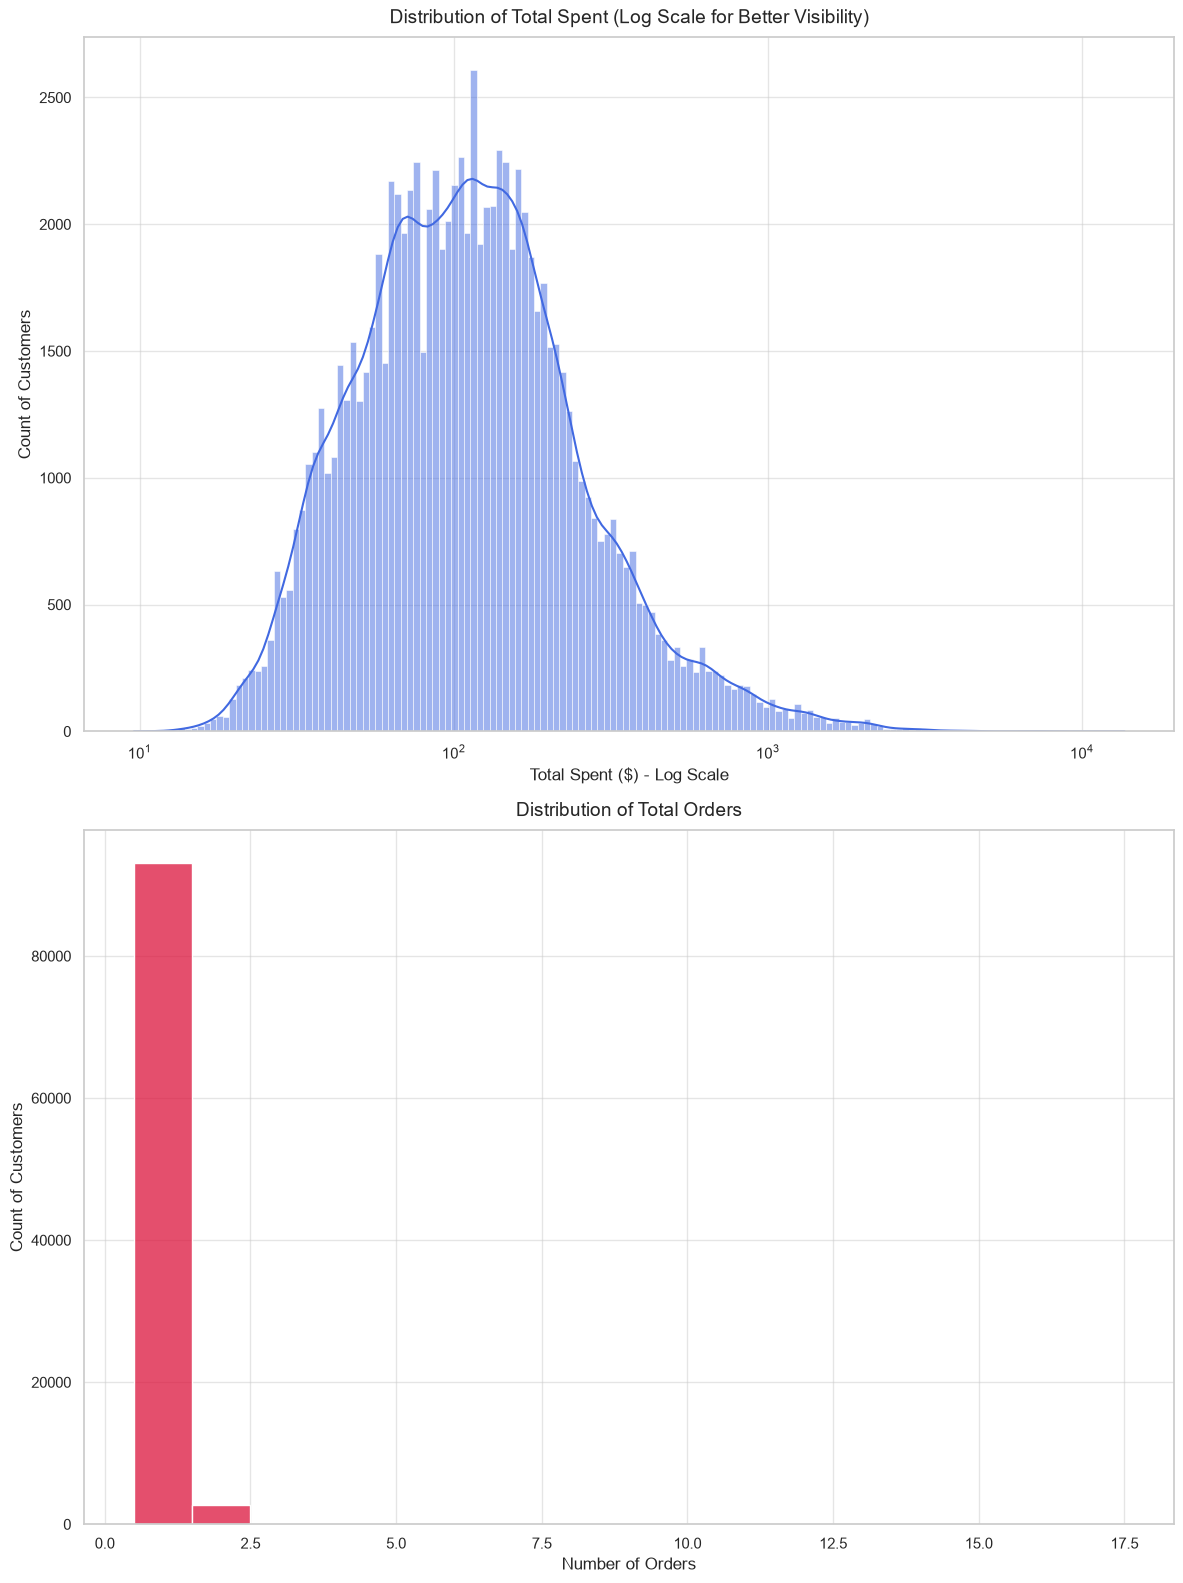

In [10]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 16))

sns.histplot(
    data=df_customers,
    x="total_spent",
    kde=True,
    color="royalblue",
    ax=axes[0],
    log_scale=True,
)
axes[0].set_title(
    "Distribution of Total Spent (Log Scale for Better Visibility)",
    fontsize=14,
    pad=10,
)
axes[0].set_xlabel("Total Spent ($) - Log Scale")
axes[0].set_ylabel("Count of Customers")


sns.histplot(
    data=df_customers,
    x="total_orders",
    kde=False,
    color="crimson",
    ax=axes[1],
    discrete=True,
)
axes[1].set_title(
    f"Distribution of Total Orders",
    fontsize=14,
    pad=10,
)
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Count of Customers")

plt.tight_layout()
plt.show()

<b>Total spent:</b> The log-scaled distribution shows that most customers spend within a central range which indicates a highly consistent purchasing behavior across the entire customer base, with very few extreme outliers on either end.

<b>Total orders:</b> The chart confirms severe retention issue, platform rarely manages to engage buyers long-term.

In [11]:
correlation_cols = ["total_orders", "failed_orders", "total_spent", "avg_order_value"]
df_corr_data = df_customers[correlation_cols]

In [12]:
corr_matrix = df_corr_data.corr(method="spearman")
corr_matrix

,total_orders,failed_orders,total_spent,avg_order_value
total_orders,1.00,0.05,0.16,0.01
failed_orders,0.05,1.00,0.01,0.01
total_spent,0.16,0.01,1.00,0.99
avg_order_value,0.01,0.01,0.99,1.00


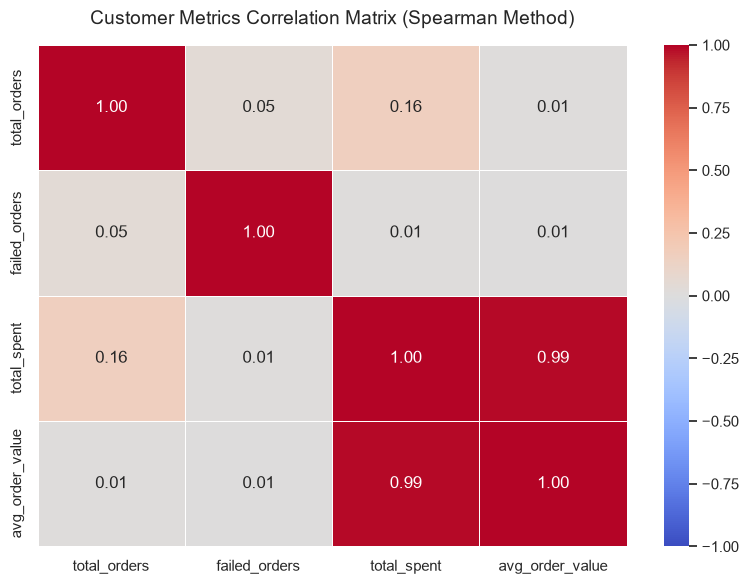

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title("Customer Metrics Correlation Matrix (Spearman Method)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

The correlation between avg_order_value and total_spent (0.99) and between total_orders and total_spent (0.16) proves once again that the total revenue generated by a customer is heavily driven by the high value of their order rather than how many times they return to buy. The correlation between total_orders and avg_order_value (0.01) gives us additional insight that even customers who happen to buy more than once do not change their habits. There is also no significant correlation between failed_orders and any other metric confirming that failed orders occur independently of order sizes and value.
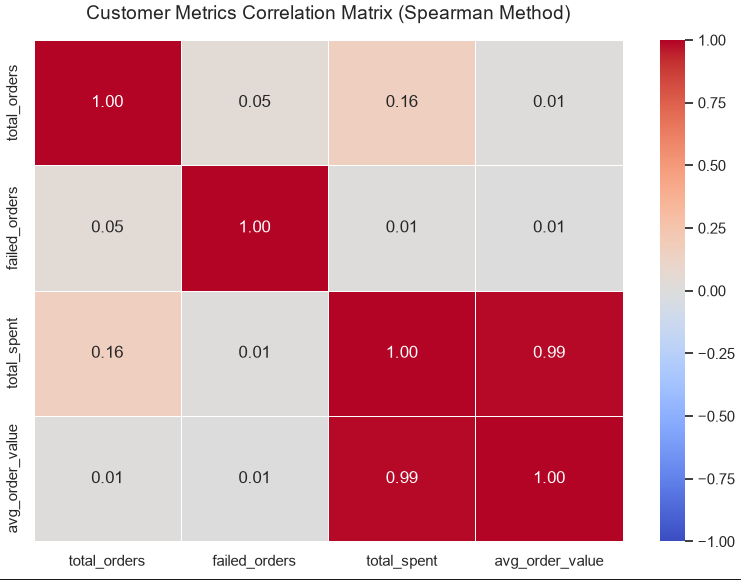

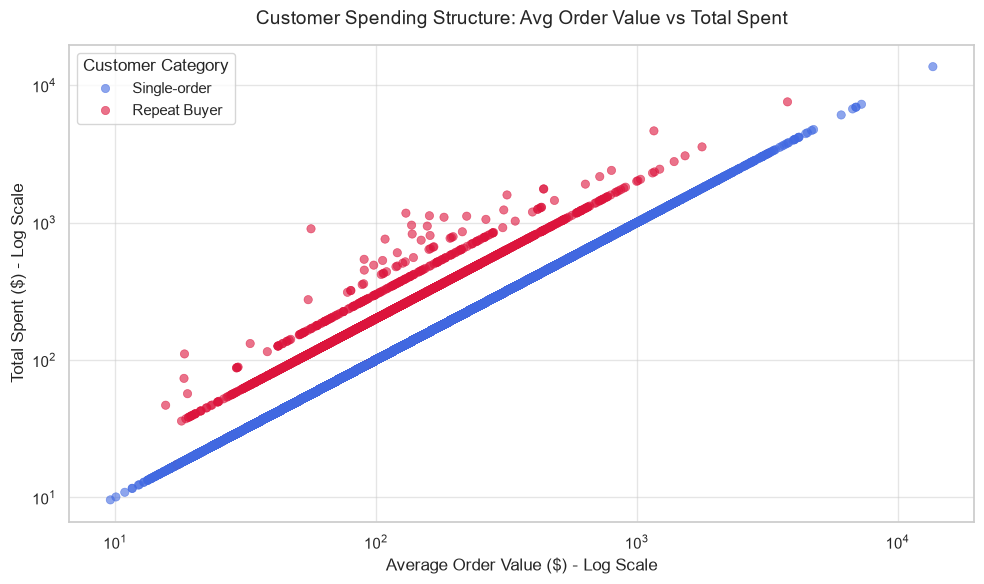

In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

df_customers["customer_type"] = df_customers["total_orders"].apply(
    lambda x: "Single-order" if x == 1 else "Repeat Buyer"
)

sns.scatterplot(
    data=df_customers,
    x="avg_order_value",
    y="total_spent",
    hue="customer_type",
    palette={"Single-order": "royalblue", "Repeat Buyer": "crimson"},
    alpha=0.6,
    edgecolor=None,
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Customer Spending Structure: Avg Order Value vs Total Spent",
    fontsize=14,
    pad=15,
)
plt.xlabel("Average Order Value ($) - Log Scale")
plt.ylabel("Total Spent ($) - Log Scale")
plt.legend(title="Customer Category")

plt.tight_layout()
plt.show()

The scatter plot confirms that the strong correlation is heavily driven by single-order customers, who form a perfect diagonal where Average Order Value equals Total Spent. Repeat buyers visibly shift above this baseline, showing exactly how much their total spending increased with each additional order.

# Products Summary Overview

In [15]:
df_products.sort_values('total_revenue', ascending=False).head(10)

,product_category_name,total_orders,products_sold,total_revenue,avg_product_price,total_freight,avg_freight
44,health_beauty,8800,9634,"1,255,695.13",130.34,"181,970.65",18.89
73,watches_gifts,5604,5970,"1,198,185.21",200.70,"100,107.26",16.77
7,bed_bath_table,9399,11097,"1,035,964.06",93.36,"204,422.07",18.42
67,sports_leisure,7673,8590,"979,740.92",114.06,"167,503.71",19.50
15,computers_accessories,6654,7781,"904,322.02",116.22,"146,619.56",18.84
39,furniture_decor,6425,8298,"727,465.05",87.67,"172,160.99",20.75
50,housewares,5847,6915,"626,825.80",90.65,"145,209.34",21.00
20,cool_stuff,3616,3779,"620,770.49",164.27,"83,315.75",22.05
5,auto,3872,4204,"586,585.73",139.53,"92,020.91",21.89
43,garden_tools,3505,4328,"481,009.94",111.14,"98,515.26",22.76


The marketplace revenue is heavily driven by the top three categories—health & beauty, watches & gifts, and bed & bath table—which are the only ones to cross the 1M milestone. Interestingly, high order volume does not always equal top revenue; for instance, watches & gifts ranks second in revenue despite having significantly fewer orders than bed & bath table due to a much higher average product price.

In [16]:
df_products["revenue_share"] = (df_products["total_revenue"] / df_products["total_revenue"].sum() * 100)

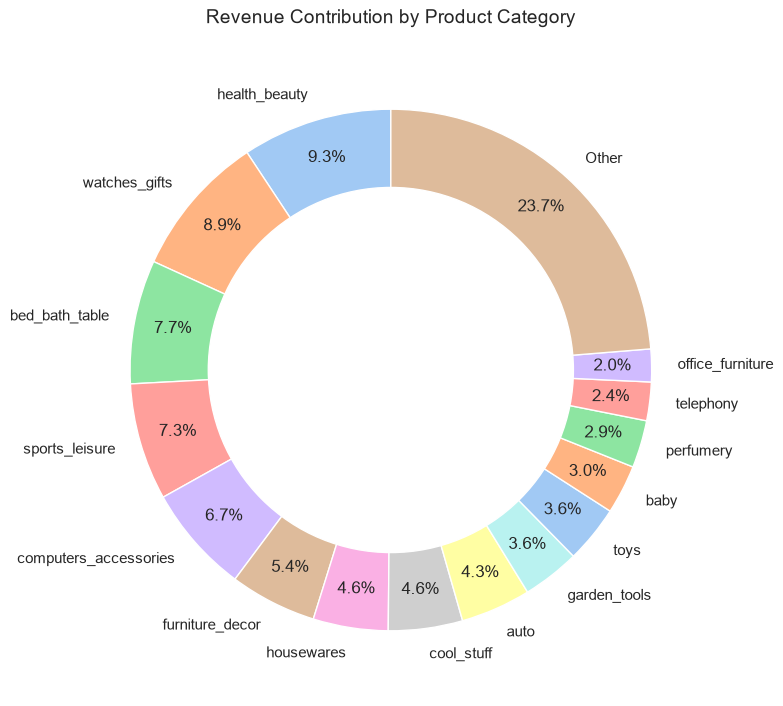

In [17]:
top_15 = df_products.sort_values(by="total_revenue", ascending=False).head(15)
other_revenue = df_products.sort_values(
    by="total_revenue", ascending=False
).iloc[15:]["total_revenue"].sum()

donut_data = pd.DataFrame(
    {
        "category": list(top_15["product_category_name"]) + ["Other"],
        "revenue": list(top_15["total_revenue"]) + [other_revenue],
    }
)

plt.figure(figsize=(8, 8))
colors = sns.color_palette("pastel")[0:16]
plt.pie(
    donut_data["revenue"],
    labels=donut_data["category"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.85,
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Revenue Contribution by Product Category", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

The chart shows a highly fragmented product catalog, with no single dominant category capturing more than 10% of total revenue. While the top five categories combined generate nearly 40% of sales, a large portion of revenue (23.7%) is tied up in a "long tail" of smaller, less prominent products.

C:\Users\kotyn\AppData\Local\Temp\ipykernel_2652\3799352329.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


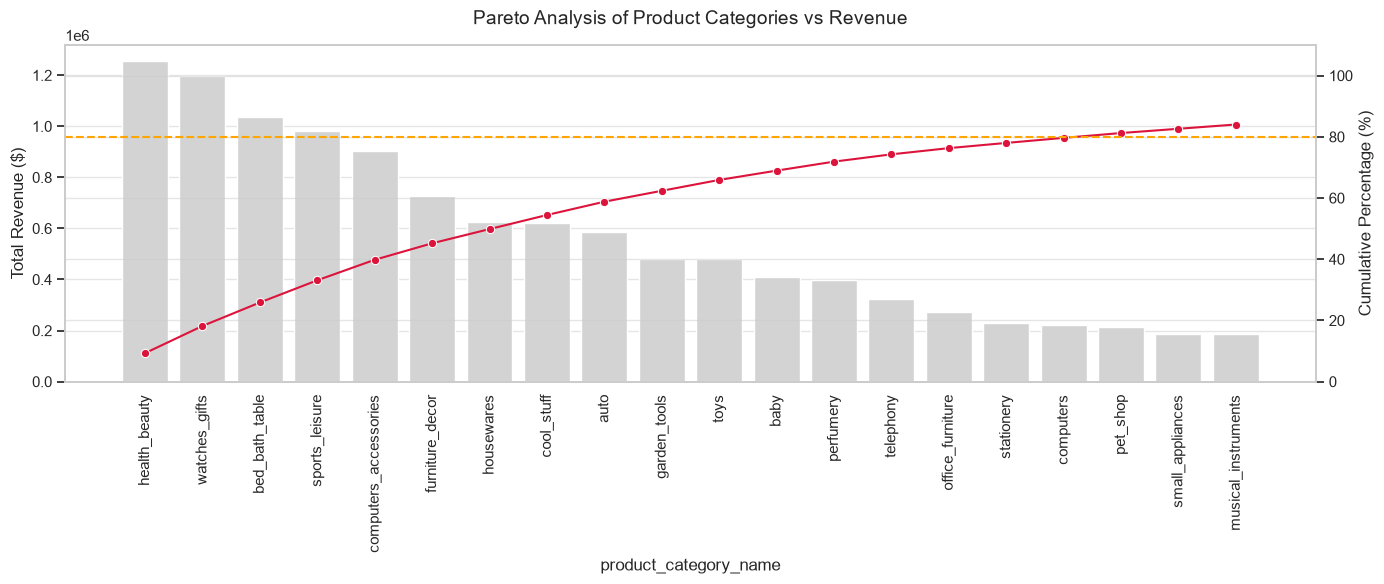

In [20]:
df_pareto = df_products.sort_values(by="total_revenue", ascending=False).copy()
df_pareto["cum_percentage"] = (
    df_pareto["total_revenue"].cumsum() / df_pareto["total_revenue"].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(14, 6))

df_pareto_skew = df_pareto.head(20)
sns.barplot(
    data=df_pareto_skew,
    x="product_category_name",
    y="total_revenue",
    ax=ax1,
    color="lightgray",
)
ax1.set_ylabel("Total Revenue ($)")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

ax2 = ax1.twinx()
sns.lineplot(
    data=df_pareto_skew,
    x="product_category_name",
    y="cum_percentage",
    ax=ax2,
    color="crimson",
    marker="o",
    sort=False,
)
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

ax2.axhline(80, color="orange", linestyle="--", label="80% Threshold")

plt.title("Pareto Analysis of Product Categories vs Revenue", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

The Pareto analysis shows that the marketplace does not follow a strict 80/20 rule; instead, it takes about 16 core categories to cross the 80% cumulative revenue threshold. This indicates a healthier, more balanced revenue distribution than expected, reducing the business risk of being overly dependent on just two or three products.

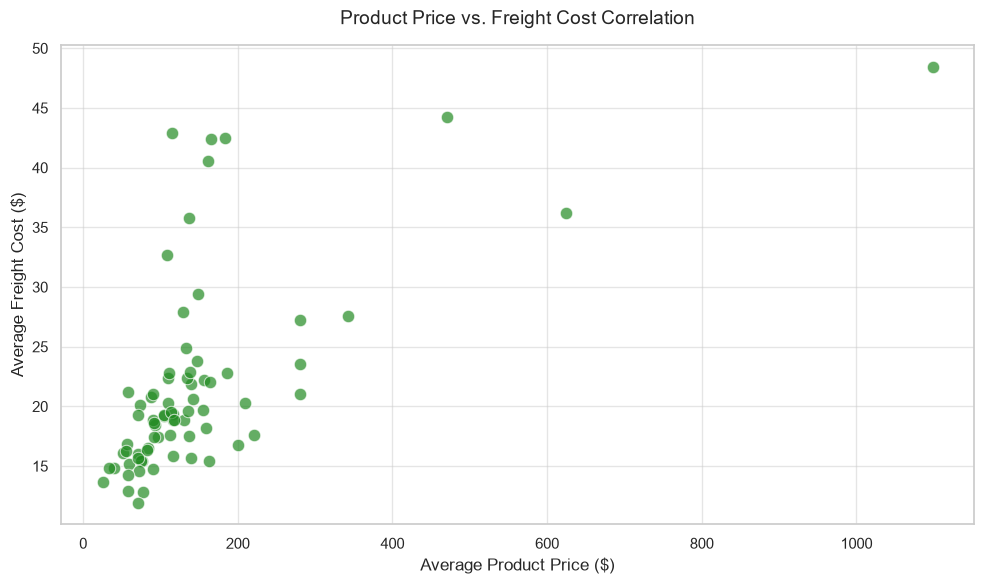

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_products,
    x="avg_product_price",
    y="avg_freight",
    alpha=0.7,
    color="forestgreen",
    edgecolor="w",
    s=80,
)

plt.title("Product Price vs. Freight Cost Correlation", fontsize=14, pad=15)
plt.xlabel("Average Product Price ($)")
plt.ylabel("Average Freight Cost ($)")
plt.tight_layout()
plt.show()

There is a weak relationship between product price and freight cost, meaning that expensive items do not automatically cost more to ship. Most categories are tightly clustered under 200 in product price, yet their shipping costs vary wildly from 12 to over 40, likely driven by differences in item weight and dimensions rather than price tags.

# Delivery Summary Overview

In [23]:
df_delivery.head()

,order_month,completed_orders,avg_delivery_days,median_delivery_days,avg_processing_days,avg_shipping_days,on_time_orders,late_orders,on_time_rate,avg_estimation_error
0,2016-09-01,1,55.00,55.00,0.00,2.00,0,1,0.00,36.00
1,2016-10-01,265,20.00,18.00,1.00,6.00,263,2,99.25,-37.00
2,2016-12-01,1,5.00,5.00,0.00,1.00,1,0,100.00,-22.00
3,2017-01-01,750,13.00,11.00,1.00,9.00,728,22,97.07,-27.00
4,2017-02-01,1653,13.00,11.00,0.00,10.00,1604,49,97.04,-19.00


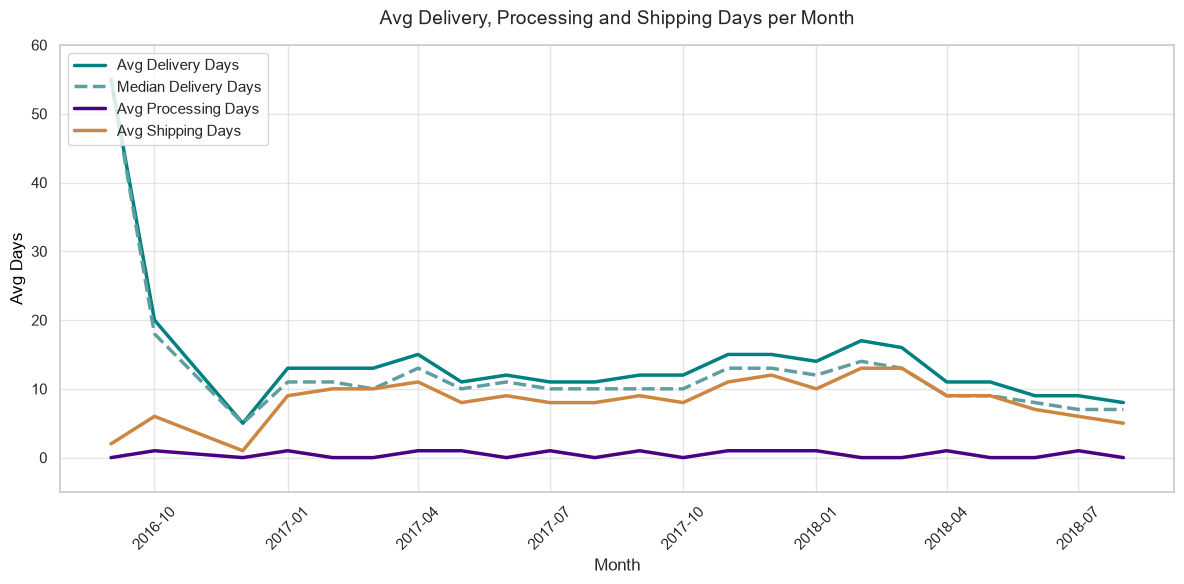

In [30]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_delivery, x='order_month', y='avg_delivery_days',
             ax=ax1, color='teal', label='Avg Delivery Days', linewidth=2.5)
sns.lineplot(data=df_delivery, x='order_month', y='median_delivery_days', linestyle="dashed",
             ax=ax1, color='cadetblue', label='Median Delivery Days', linewidth=2.5)
sns.lineplot(data=df_delivery, x='order_month', y='avg_processing_days',
             ax=ax1, color='indigo', label='Avg Processing Days', linewidth=2.5)
sns.lineplot(data=df_delivery, x='order_month', y='avg_shipping_days',
             ax=ax1, color='peru', label='Avg Shipping Days', linewidth=2.5)

ax1.set_ylabel('Avg Days', color='black')
ax1.set_ylim(-5,60)
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

plt.title('Avg Delivery, Processing and Shipping Days per Month', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The internal order processing and shipping days remain low and stable throughout the entire period. After the spike during platform launch in lat 20216 average delivery days stabilized.

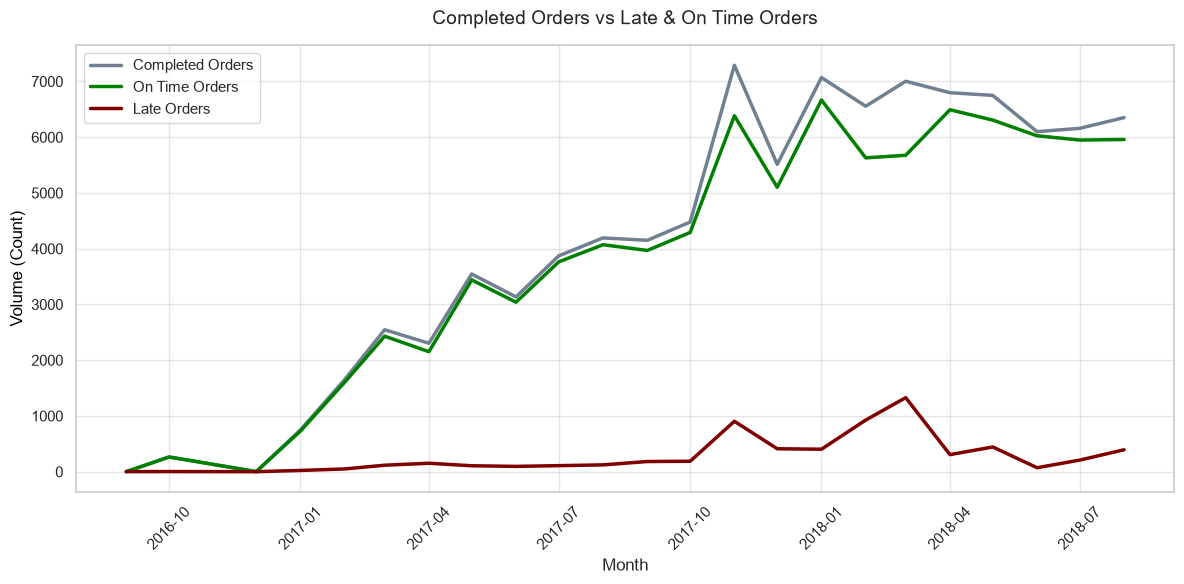

In [34]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_delivery, x='order_month', y='completed_orders',
             ax=ax1, color='slategrey', label='Completed Orders', linewidth=2.5)
sns.lineplot(data=df_delivery, x='order_month', y='on_time_orders',
             ax=ax1, color='green', label='On Time Orders', linewidth=2.5)
sns.lineplot(data=df_delivery, x='order_month', y='late_orders',
             ax=ax1, color='maroon', label='Late Orders', linewidth=2.5)


ax1.set_ylabel('Volume (Count)', color='black')

ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

plt.title('Completed Orders vs Late & On Time Orders', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The vast majority of completed orders are delivered on time, with the green line closely following the total volume trend. Late orders remained negligible during initial growth but experienced noticeable, temporary spikes during peak volume periods in late 2017 and early 2018 before stabilizing again.

# Order Reviews Overview

In [59]:
df_reviews.head()

,review_id,order_id,customer_unique_id,review_score,review_sentiment,order_status,successful_order,purchase_month,delivery_days,delivery_delay_days,is_late_delivery
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,68a5590b9926689be4e10f4ae2db21a8,4,Positive,delivered,True,2018-01-01,6.00,-16.00,False
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,64190b91b656ab8f37eb89b93dc84584,5,Positive,delivered,True,2018-02-01,9.00,-5.00,False
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,1d47144362c14e94ccdd213e8ec277d5,5,Positive,delivered,True,2018-02-01,13.00,-21.00,False
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,c8cf6cb6b838dc7a33ed199b825e8616,5,Positive,delivered,True,2017-04-01,11.00,-20.00,False
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,d16000272660a1fef81482ad75ba572a,5,Positive,delivered,True,2018-02-01,18.00,-9.00,False


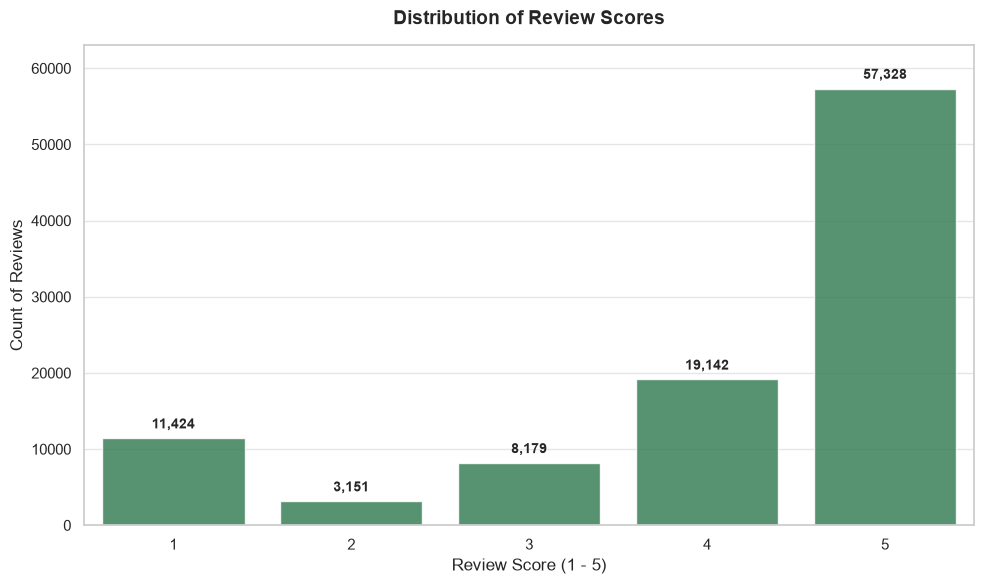

In [48]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))


ax = sns.countplot(
    data=df_reviews,
    x="review_score",
    color="seagreen",
    alpha=0.85,
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=10,
        weight="semibold",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.title("Distribution of Review Scores", fontsize=14, pad=15, weight="bold")
plt.xlabel("Review Score (1 - 5)")
plt.ylabel("Count of Reviews")

plt.ylim(0, df_reviews["review_score"].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

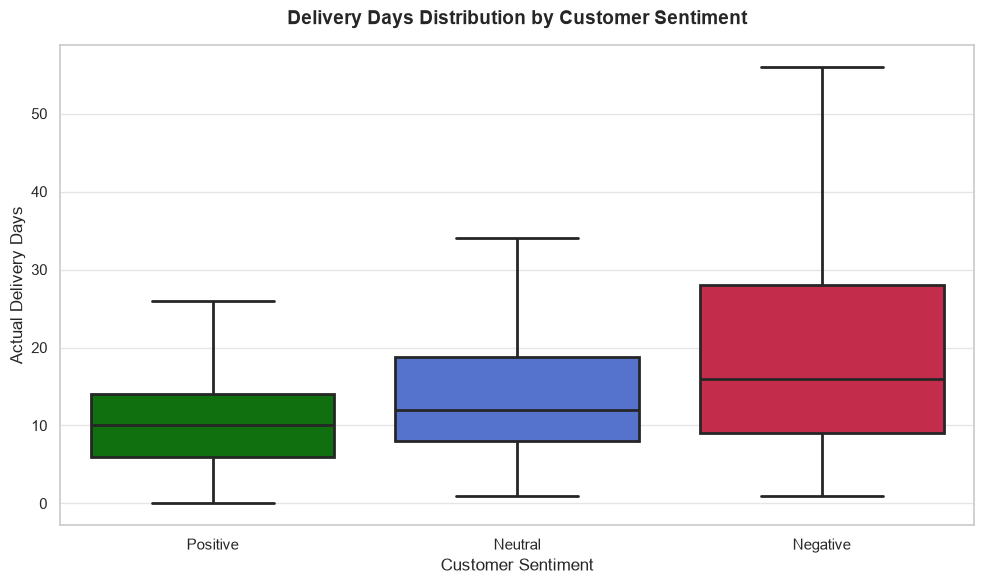

In [54]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_reviews,
    x="review_sentiment",
    y="delivery_days",
    order=["Positive", "Neutral", "Negative"],
    hue="review_sentiment",
    palette= ["green", "crimson", "royalblue"],
    legend= False,
    showfliers=False,
    linewidth=2
)

plt.title("Delivery Days Distribution by Customer Sentiment", fontsize=14, pad=15, weight="bold")
plt.xlabel("Customer Sentiment")
plt.ylabel("Actual Delivery Days")

plt.tight_layout()
plt.show()

Shipping performance is a primary driver of customer satisfaction, as the median delivery time for negative reviews is noticeably higher at around 16 days compared to just 10 days for positive ones. Furthermore, the wide spread in the negative category shows that extreme delivery delays—sometimes stretching over 50 days—almost guarantee poor customer sentiment.

# Cross-View Analysis

## Geographical Satisfaction and Logistics

In [81]:
df_customers_reviews = pd.merge(df_customers, df_reviews, on="customer_unique_id")

In [82]:
df_geo = df_customers_reviews.groupby("customer_state").agg({
    "total_orders": "sum",
    "review_score": "mean",
    "delivery_days": "mean"
})

In [83]:
df_geo.sort_values("total_orders", ascending=False).head(5)

,total_orders,review_score,delivery_days
customer_state,,,
SP,45439,4.17,8.69
RJ,13886,3.87,15.18
MG,12558,4.14,11.93
RS,5959,4.13,15.25
PR,5433,4.18,11.93


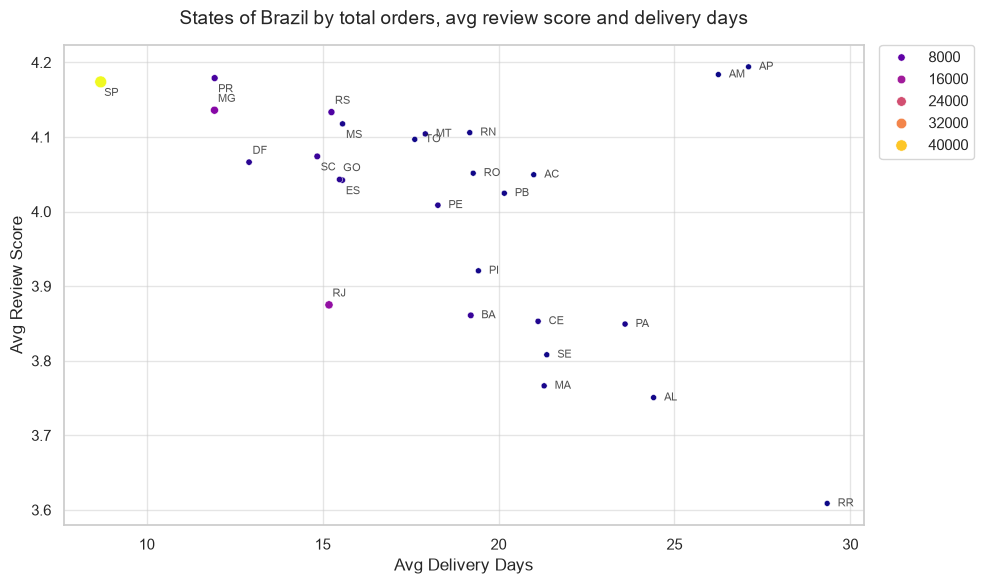

In [84]:
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=df_geo,
    x="delivery_days",
    y="review_score",
    size="total_orders",
    hue="total_orders",
    palette="plasma"
)
for i, (idx, row) in enumerate(df_geo.iterrows()):
    x_pos = row["delivery_days"]
    y_pos = row["review_score"]

    if x_pos < 16:
        if i % 2 == 0:
            y_pos += 0.015
        else:
            y_pos -= 0.015
        x_shift = 0.1
    else:
        x_shift = 0.3

    ax.text(
        x=x_pos + x_shift,
        y=y_pos,
        s=str(idx),
        fontsize=8,
        alpha=0.8,
        va="center"
    )

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.title("States of Brazil by total orders, avg review score and delivery days", fontsize=14, pad=15)
plt.xlabel("Avg Delivery Days")
plt.ylabel("Avg Review Score")
plt.tight_layout()
plt.show()

There is a clear negative correlation between logistical performance and customer satisfaction, as states with longer delivery times show a significant drop in review scores. São Paulo (SP) dominates the market as a major outlier, delivering the highest volume of orders with the fastest transit times and top-tier ratings.

## Customers Sentiment

In [95]:
df_sentiment = df_customers_reviews.groupby("customer_unique_id").agg({
    "total_spent": "sum",
    "review_score": "mean",
    "total_orders": "sum",
    "failed_orders": "sum"
})

In [96]:
df_sentiment

,total_spent,review_score,total_orders,failed_orders
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,5.00,1,0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,4.00,1,0
0000f46a3911fa3c0805444483337064,86.22,3.00,1,0
0000f6ccb0745a6a4b88665a16c9f078,43.62,4.00,1,0
0004aac84e0df4da2b147fca70cf8255,196.89,5.00,1,0
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,"2,067.42",5.00,1,0
fffea47cd6d3cc0a88bd621562a9d061,84.58,4.00,1,0
ffff371b4d645b6ecea244b27531430a,112.46,5.00,1,0


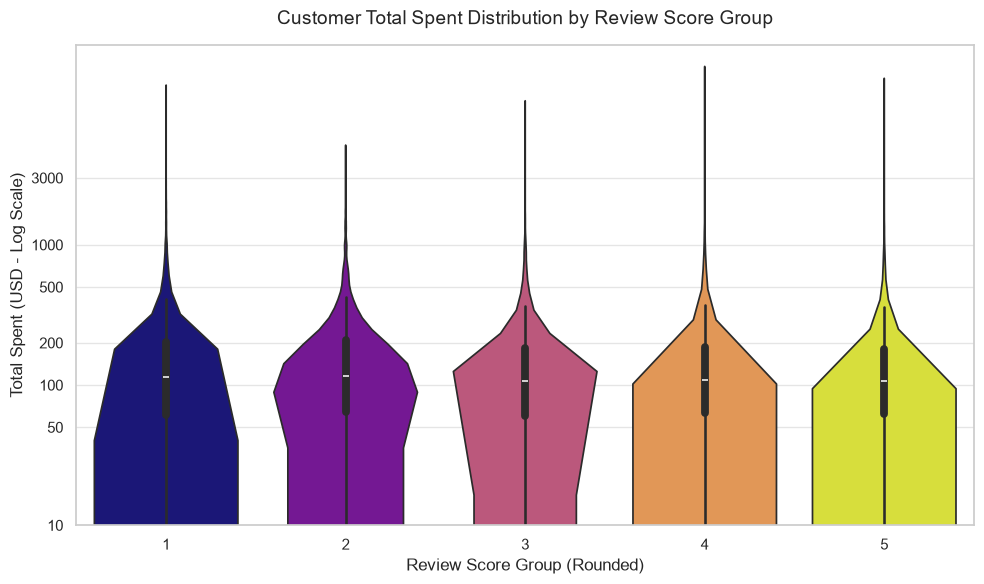

In [97]:

df_sentiment['review_group'] = df_sentiment['review_score'].round().astype(int)

plt.figure(figsize=(10, 6))

ax = sns.violinplot(
    data=df_sentiment,
    x='review_group',
    y='total_spent',
    palette='plasma',
    hue='review_group',
    legend=False
)

ax.set_yscale('log')

ax.set_yticks([10, 50, 100, 200, 500, 1000, 3000])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

plt.title("Customer Total Spent Distribution by Review Score Group", fontsize=14, pad=15)
plt.xlabel("Review Score Group (Rounded)")
plt.ylabel("Total Spent (USD - Log Scale)")

plt.tight_layout()
plt.show()

The analysis shows no correlation between a customer's total expenditure and their review scores, as the spending distribution remains identical across all rating groups. This indicates that customer satisfaction on Olist is driven by operational factors like delivery performance rather than the transaction value.

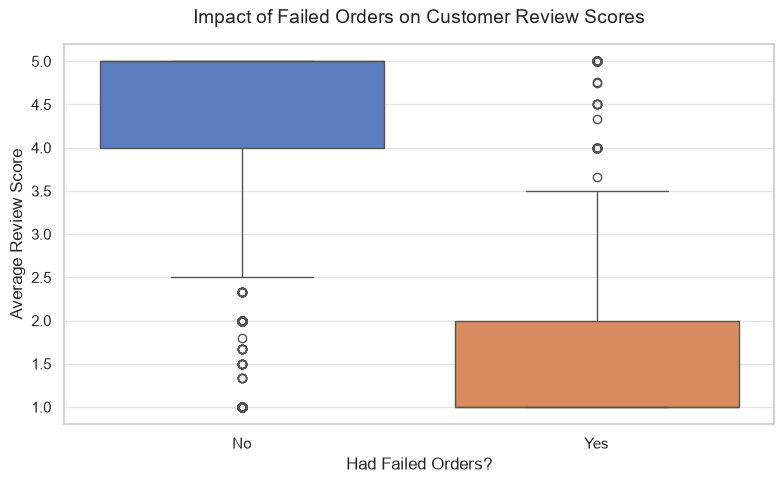

In [101]:
df_sentiment_copy = df_sentiment.copy()
# Tworzymy flagę: czy klient miał chociaż jedno nieudane zamówienie
df_sentiment_copy['had_failed_orders'] = df_sentiment_copy['failed_orders'].apply(lambda x: 'Yes' if x > 0 else 'No')

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_sentiment_copy,
    x='had_failed_orders',
    y='review_score',
    hue='had_failed_orders',
    palette='muted'
)

plt.title("Impact of Failed Orders on Customer Review Scores", fontsize=14, pad=15)
plt.xlabel("Had Failed Orders?")
plt.ylabel("Average Review Score")
plt.tight_layout()
plt.show()

A single failed order severely damages customer loyalty, dropping the median review score from 5.0 to 1.0. This highlights that operational failures have a critical impact on customer perception, leaving almost no room for error in order fulfillment.

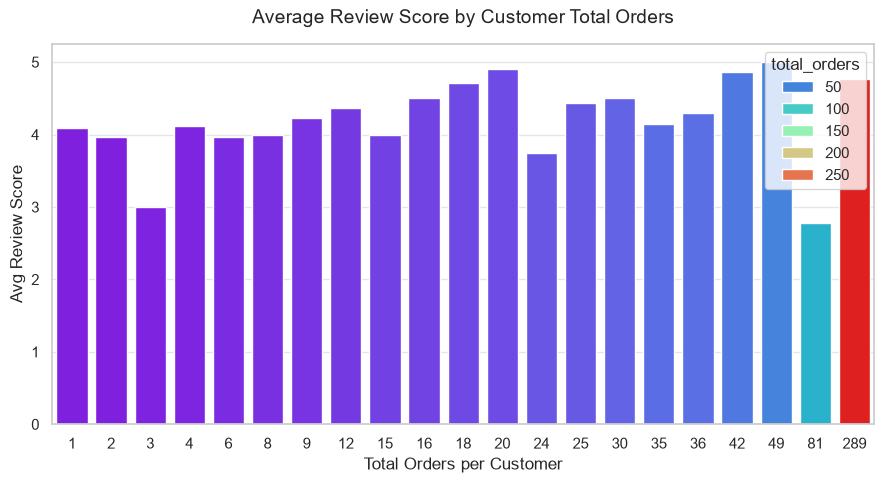

In [105]:
plt.figure(figsize=(9, 5))

# Pokazujemy rozkład ocen w zależności od łącznej liczby zamówień klienta
sns.barplot(
    data=df_sentiment,
    x='total_orders',
    y='review_score',
    errorbar=None,
    hue='total_orders',
    palette= 'rainbow'
)

plt.title("Average Review Score by Customer Total Orders", fontsize=14, pad=15)
plt.xlabel("Total Orders per Customer")
plt.ylabel("Avg Review Score")
plt.tight_layout()
plt.show()

There is no impact between avg review score and number of orders per customer.

## Sales vs Delivery

In [108]:
df_logistics = pd.merge(df_monthly_sales, df_delivery, left_on="purchase_month", right_on="order_month")

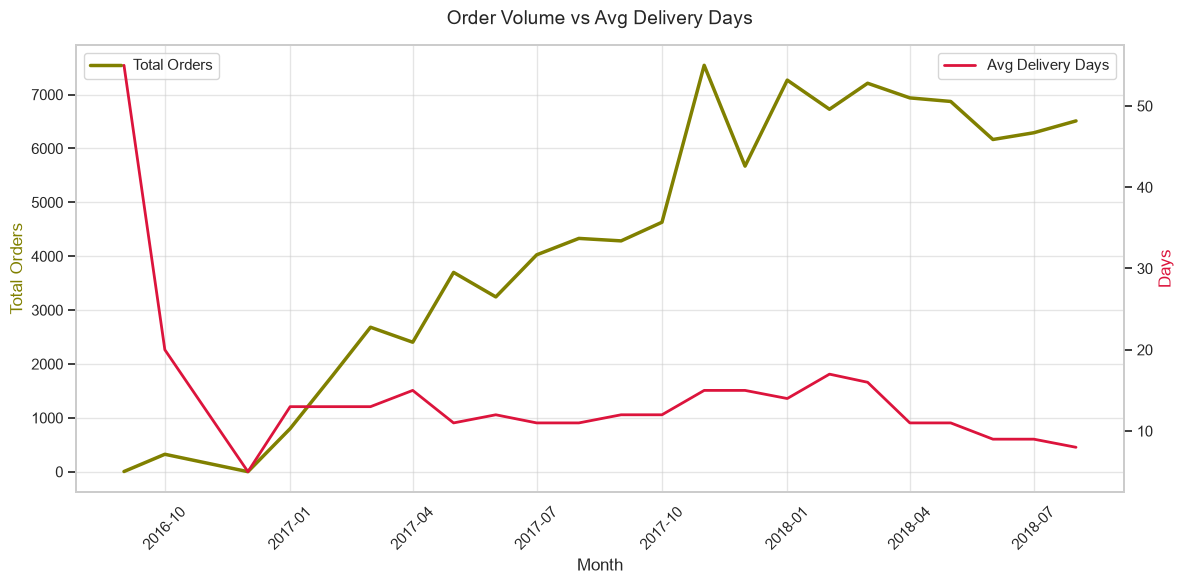

In [112]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df_logistics, x='purchase_month', y='total_orders',
             ax=ax1, color='olive', label='Total Orders', linewidth=2.5)

ax1.set_ylabel('Total Orders', color='olive')
ax1.set_xlabel('Month')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=df_logistics, x='purchase_month', y='avg_delivery_days',
             ax=ax2, color='crimson', label='Avg Delivery Days', linewidth=2)

ax2.set_ylabel('Days', color='crimson')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.title('Order Volume vs Avg Delivery Days', fontsize=14, pad=15)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Operational performance shows remarkable stability, as the average delivery time remains consistent despite a massive growth in monthly order volume. This indicates that Olist’s logistics network scales effectively during high-demand peaks without causing delivery bottlenecks.

# Summary

1. Olist suffers from very low customer retention, and loyal customers do not display higher spending habits.
2. The platform offers a highly diverse range of product categories.
3. Revenue growth is driven entirely by sales volume and new customer acquisition.
4. Order delivery speed and fulfillment success are the strongest predictors of customer satisfaction. However, the majority of reviews remain positive.
5. The vast majority of orders are delivered on time. Average delivery times are shortest in São Paulo (Olist's central hub) and longest in Roraima. This issue is not Olist specific, Roraima ranks consistently as the most difficult and slowest state for deliveries in Brazi, mostly due to a near-total reliance on waterways, and massive infrastructure gaps in the Amazon.